# Modelagem

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import(
    balanced_accuracy_score, 
    confusion_matrix, 
    classification_report, 
    RocCurveDisplay, 
    roc_auc_score, 
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    brier_score_loss
)
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_validate, GridSearchCV, train_test_split, StratifiedKFold
from sklearn.calibration import calibration_curve
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import SelectFromModel


from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# Funções Gerais

In [2]:
def plot_model_metrics(model, X_test, y_test, threshold=0.5, model_name="Model"):
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Aplicar threshold
    y_pred = (y_proba >= threshold).astype(int)
    
    print(f"{'='*60}")
    print(f"Avaliação do modelo: {model_name}")
    print(f"{'='*60}")
    
    # metricas principais
    auc_score = roc_auc_score(y_test, y_proba)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    
    print(f"AUC: {auc_score:.4f}")
    print(f"Balanced Accuracy: {bal_acc:.4f}")
    
    # classification report
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    
    # matriz de confusao
    cm = confusion_matrix(y_test, y_pred, normalize="true")
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["Real 0", "Real 1"]
    )
    
    plt.title(f"Confusion Matrix - {model_name}")
    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.show()
    
    # curva roc
    plt.figure(figsize=(8, 6))
    ax = plt.gca()
    
    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        ax=ax
    )
    
    plt.title(f"ROC Curve - {model_name}")
    plt.show()

In [3]:
def feature_importance_plot_pipeline(pipeline, X, output_image_path, model_name="Model"):
    '''
    '''
    model = pipeline.named_steps['classifier']
    preprocessor = pipeline.named_steps['preprocessing']
    selector = pipeline.named_steps['feature_selection']

    feature_names = preprocessor.get_feature_names_out()

    mask = selector.get_support()
    selected_features = feature_names[mask]

    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_

    elif hasattr(model, "get_feature_importance"):
        importances = model.get_feature_importance()

    else:
        raise ValueError("Modelo não possui feature importance disponível")

    df_importance = pd.DataFrame({
        "feature": selected_features,
        "importance": importances
    }).sort_values(by="importance", ascending=False)

    plt.figure(figsize=(12, 6))
    plt.bar(df_importance["feature"], df_importance["importance"])
    plt.title(f"Feature Importance - {model_name}")
    plt.ylabel("Importance")
    plt.xticks(rotation=90)

    plt.tight_layout()
    plt.savefig(output_image_path)
    plt.show()

    return df_importance

In [4]:
def find_best_threshold(y_true, y_proba, fp_cost=1, fn_cost=5):
    y_true = np.array(y_true).ravel()
    y_proba = np.array(y_proba).ravel()
    
    thresholds = np.linspace(0, 1, 100)
    best_cost = float('inf')
    best_threshold = 0
    
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        
        fp = ((y_true == 0) & (y_pred == 1)).sum()
        fn = ((y_true == 1) & (y_pred == 0)).sum()
        
        cost = fp * fp_cost + fn * fn_cost
        
        if cost < best_cost:
            best_cost = cost
            best_threshold = t
            
    return best_threshold, best_cost

# Divisão dos dados em treino, validação e teste

In [5]:
train_set = pd.read_parquet('../data/curated/train.parquet', engine="fastparquet")
test_set = pd.read_parquet('../data/curated/test.parquet', engine="fastparquet")

In [6]:
# converter tipagem algumas colunas
cat_cols = train_set.select_dtypes(include=["object"]).columns.tolist()
num_cols = train_set.select_dtypes(exclude=["object"]).columns.tolist()

# converter categóricas
for col in cat_cols:
    train_set[col] = train_set[col].astype("category")

In [7]:
train, val = train_test_split(
    train_set,
    test_size=0.20,
    random_state=42,
    stratify=train_set["target"]
)

In [8]:
print(train.target.value_counts())
print(val.target.value_counts())

target
0    116985
1       527
Name: count, dtype: int64
target
0    29246
1      132
Name: count, dtype: int64


In [9]:
X_train = train.drop("target", axis=1)
y_train = train[["target"]]

X_val = val.drop("target", axis=1)
y_val = val[["target"]]

## Pipelines

In [10]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        
        # evitar divisão por zero
        eps = 1e-6
        
        # Relações financeiras
        X['ratio_credit_income'] = X['valor_credito'] / (X['renda_anual'] + eps)
        X['ratio_installment_income'] = X['valor_parcela'] / (X['renda_anual'] + eps)
        X['ltv'] = X['valor_bem'] / (X['valor_credito'] + eps)
        X['installment_ratio_credit'] = X['valor_parcela'] / (X['valor_credito'] + eps)
        
        # Histórico
        X['credit_vs_history_mean'] = X['valor_credito'] / (X['hist_valor_credito_mean'] + eps)
        X['installment_vs_history_mean'] = X['valor_parcela'] / (X['hist_valor_parcela_mean'] + eps)
        
        # Perfil familiar
        X['income_per_capita'] = X['renda_anual'] / (X['qtd_membros_familia'] + eps)
        X['dependents_ratio'] = X['qtd_filhos'] / (X['qtd_membros_familia'] + eps)
        
        # Temporal
        X['is_weekend'] = X['dia_semana_solicitacao'].isin(['SATURDAY', 'SUNDAY']).astype(int)
        
        return X

In [11]:
def get_scoring():
    return {
        'balanced_accuracy': make_scorer(balanced_accuracy_score),
        'f1': make_scorer(f1_score),
        'precision': make_scorer(precision_score),
        'recall': make_scorer(recall_score),  # sensibilidade
        'specificity': make_scorer(recall_score, pos_label=0)  # especificidade
    }


def get_models():
    return {
        'lightgbm': LGBMClassifier(
            random_state=42,
            class_weight='balanced',
            n_jobs=-1
        ),
        'xgboost': XGBClassifier(
            random_state=42,
            eval_metric='logloss',
            enable_categorical=True,
            n_jobs=-1
        )
    }


def build_preprocessor(X):

    categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    numerical_cols = X.select_dtypes(exclude=['object', 'category']).columns.tolist()

    cat_pipeline = make_pipeline(
        SimpleImputer(strategy='most_frequent'),
        OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    )

    num_pipeline = make_pipeline(
        SimpleImputer(strategy='median')
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', cat_pipeline, categorical_cols),
            ('num', num_pipeline, numerical_cols)
        ]
    )

    return preprocessor, categorical_cols, numerical_cols


def build_pipeline(model, X, selector_model=None):

    preprocessor, cat_cols, num_cols = build_preprocessor(X)

    # modelo usado para selecionar features
    if selector_model is None:
        selector_model = LGBMClassifier(
            random_state=42,
            n_jobs=-1
        )

    return Pipeline(
        steps=[
            ('feature_engineering', FeatureEngineer()),
            ('preprocessing', preprocessor),
            ('feature_selection', SelectFromModel(
                estimator=selector_model,
                threshold='median'  # pode tunar depois
            )),
            ('under', RandomUnderSampler(random_state=42)),
            ('classifier', model)
        ]
    )


def run_models_cv(X, y, cv_splits=5):

    models = get_models()
    scoring = get_scoring()

    cv = StratifiedKFold(
        n_splits=cv_splits,
        shuffle=True,
        random_state=42
    )

    results = []

    for model_name, model in models.items():

        print(f"Treinando modelo: {model_name}")

        pipe = build_pipeline(model, X)

        scores = cross_validate(
            pipe,
            X,
            y,
            cv=cv,
            scoring=scoring,
            return_train_score=True,
            n_jobs=-1
        )

        # agrega resultados
        model_result = {'model': model_name}

        for metric in scoring.keys():
            model_result[f'{metric}_train'] = np.mean(scores[f'train_{metric}'])
            model_result[f'{metric}_test'] = np.mean(scores[f'test_{metric}'])

        results.append(model_result)

    return pd.DataFrame(results)

In [12]:
df_results = run_models_cv(X_train, y_train)
df_results

Treinando modelo: lightgbm
Treinando modelo: xgboost


,model,balanced_accuracy_train,balanced_accuracy_test,f1_train,f1_test,precision_train,precision_test,recall_train,recall_test,specificity_train,specificity_test
0,lightgbm,0.841032,0.714733,0.027603,0.020634,0.013995,0.010461,1.0,0.749524,0.682064,0.679942
1,xgboost,0.840751,0.716089,0.027546,0.020726,0.013966,0.010508,1.0,0.751500,0.681502,0.680677


## Tunning dos hiperparâmetros

In [ ]:
# MODELOS
model = LGBMClassifier(
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

selector_model = LGBMClassifier(
    random_state=42,
    n_jobs=-1
)

# PIPELINE
preprocessor, cat_cols, num_cols = build_preprocessor(X_train)

final_model = Pipeline(
    steps=[
        ('feature_engineering', FeatureEngineer()),

        ('preprocessing', preprocessor),

        ('feature_selection', SelectFromModel(
            estimator=selector_model,
            threshold='median'
        )),

        ('under', RandomUnderSampler(random_state=42)),

        ('classifier', model)
    ]
)

# PARAM GRID (LIGHTGBM)
param_grid = {
    # modelo
    'classifier__n_estimators': [200, 400],
    'classifier__max_depth': [-1, 6, 10],

    # regularização
    'classifier__min_child_samples': [5, 20, 50],
    
    # feature selection (🔥 MUITO importante)
    'feature_selection__threshold': [
        'median',
        'mean',
        '1.25*mean',
    ]
}

# GRID SEARCH
grid_search = GridSearchCV(
    estimator=final_model,
    param_grid=param_grid,
    cv=5,
    scoring={
        'precision': 'precision',
        'balanced_accuracy': 'balanced_accuracy',
        'f1': 'f1'
    },
    refit='precision',
    return_train_score=True,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# RESULTADOS
print('Best params:', grid_search.best_params_)
print('Best precision:', grid_search.best_score_)

final_model = grid_search.best_estimator_

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
[LightGBM] [Info] Number of positive: 527, number of negative: 116985
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.063913 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4994
[LightGBM] [Info] Number of data points in the train set: 117512, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.004485 -> initscore=-5.402600
[LightGBM] [Info] Start training from score -5.402600
[LightGBM] [Info] Number of positive: 527, number of negative: 527
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000929 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4057
[LightGBM] [Info] Number of data points in the train set: 1054, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGB

In [14]:
results = pd.DataFrame(grid_search.cv_results_)
metrics = ['balanced_accuracy', 'f1']
best_metrics = {}

print("\nBest metrics for each calculated metric:\n")
for metric in metrics:
    best_train_metric = results[f'mean_train_{metric}'][grid_search.best_index_]
    best_val_metric = results[f'mean_test_{metric}'][grid_search.best_index_]
    print(f"Best training {metric}: {best_train_metric:.4f}")
    print(f"Best validation {metric}: {best_val_metric:.4f}")

    best_metrics[f'train_{metric}'] = best_train_metric
    best_metrics[f'validation_{metric}'] = best_val_metric


Best metrics for each calculated metric:

Best training balanced_accuracy: 0.8372
Best validation balanced_accuracy: 0.7102
Best training f1: 0.0269
Best validation f1: 0.0201


## Calibração do Modelo e Melhor Threshold

Best threshold: 1.0000
Business cost: 660


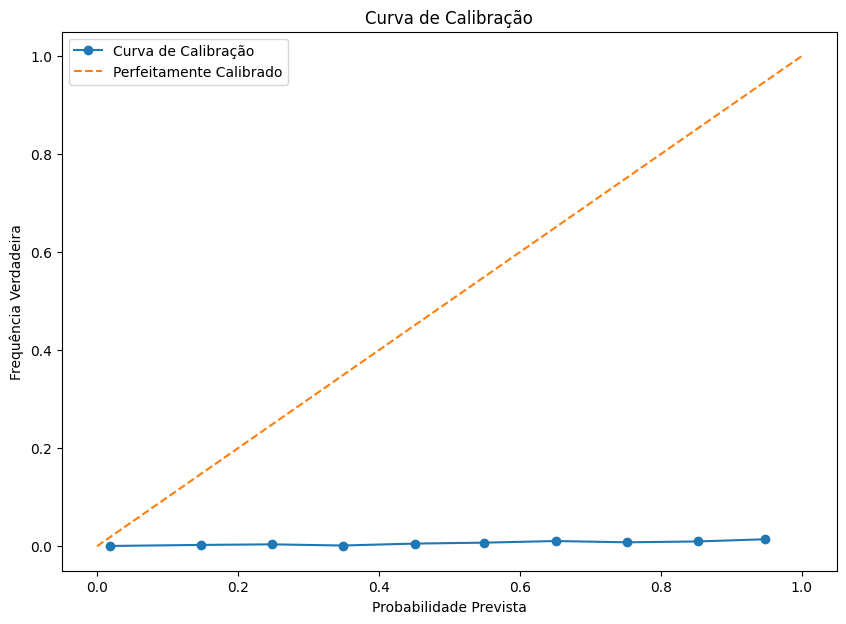

Brier score: 0.23555693792357155


In [15]:
y_proba = final_model.predict_proba(X_val)[:, 1]

best_threshold, best_cost = find_best_threshold(
    y_val,
    y_proba,
    fp_cost=1,
    fn_cost=5
)

print(f"Best threshold: {best_threshold:.4f}")
print(f"Business cost: {best_cost}")

prob_true, prob_pred = calibration_curve(y_val, y_proba, n_bins=10)
plt.figure(figsize=(10, 7))
plt.plot(prob_pred, prob_true, marker='o', label='Curva de Calibração')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfeitamente Calibrado')
plt.xlabel('Probabilidade Prevista')
plt.ylabel('Frequência Verdadeira')
plt.title('Curva de Calibração')
plt.legend()
plt.show()

brier_score = brier_score_loss(y_val, y_proba)
print(f'Brier score: {brier_score}')

## Feature Importance

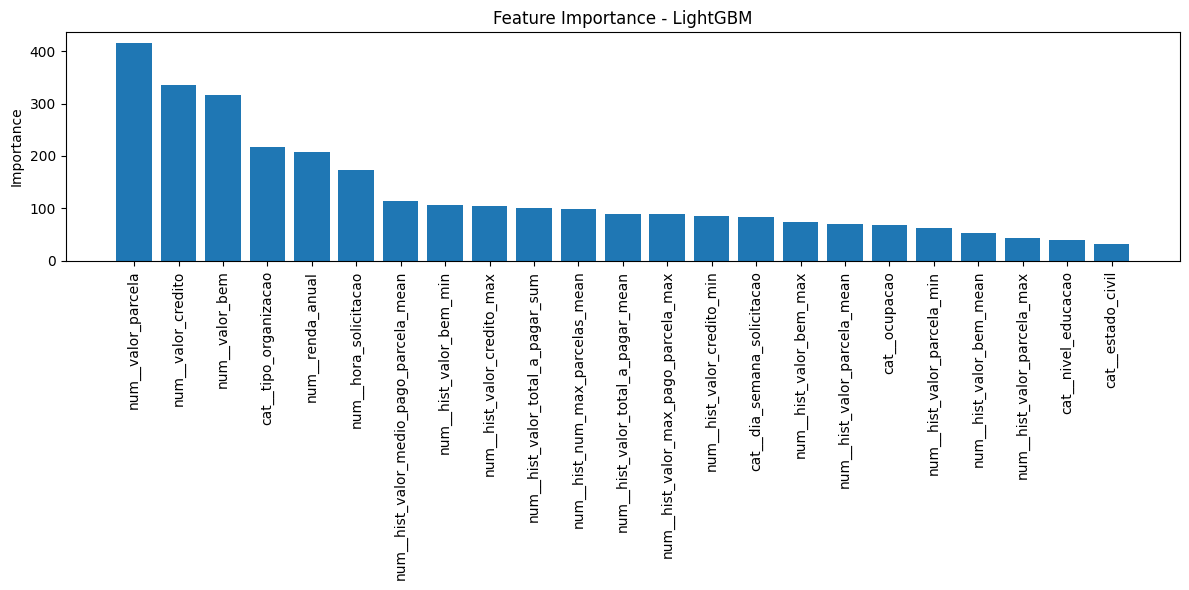

In [16]:
pipe = grid_search.best_estimator_

df_importance = feature_importance_plot_pipeline(
    pipeline=pipe,
    X=X_train,
    output_image_path="fi_lgbm.png",
    model_name="LightGBM"
)

## Aplicação do modelo nos dados de validação

Avaliação do modelo: XGBoost
AUC: 0.7823
Balanced Accuracy: 0.7278
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.67      0.80     29246
           1       0.01      0.79      0.02       132

    accuracy                           0.67     29378
   macro avg       0.50      0.73      0.41     29378
weighted avg       0.99      0.67      0.80     29378



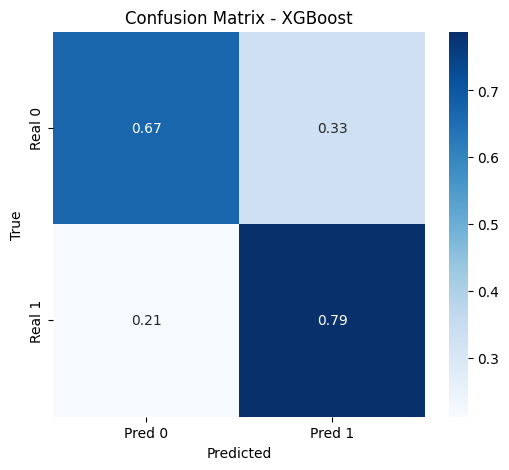

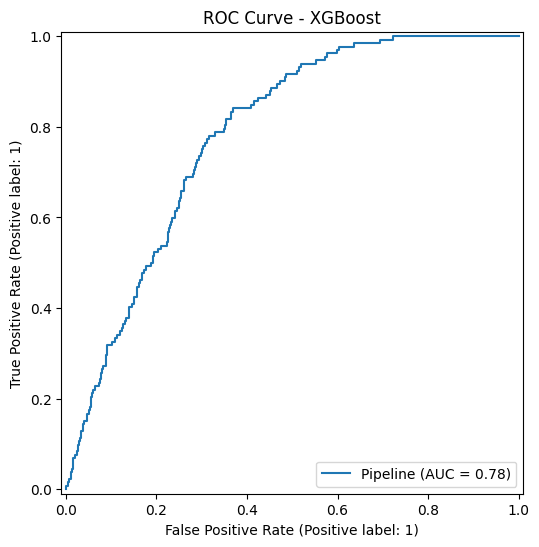

In [17]:
# Evaluate final model
plot_model_metrics(final_model, X_val, y_val, model_name="XGBoost", threshold=0.5)

## Aplicação do modelo nos dados de teste

In [18]:
y_proba = final_model.predict_proba(test_set)[:, 1]
submissao = test_set[['id_cliente']].copy()
submissao['probabilidade_inadimplencia'] = y_proba
submissao.to_csv('submissao_case.csv', index=False)

In [19]:
submissao

,id_cliente,probabilidade_inadimplencia
0,100023,0.022780
1,100031,0.426915
2,100056,0.034570
3,100069,0.005897
4,100085,0.078680
...,...,...
39995,455962,0.924380
39996,456007,0.030137
39997,456009,0.002214
39998,456119,0.521490
